In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Kuramoto Phase Oscillators

The **Kuramoto model** is the canonical model of synchronization in a population of coupled phase oscillators. Each oscillator $i$ has a natural frequency $\omega_i$ and is pulled toward its neighbours' phases:

$$\dot\theta_i = \omega_i + \frac{K}{N}\sum_j W_{ij}\sin(\theta_j - \theta_i).$$

Below a critical coupling $K_c$ the oscillators drift incoherently; above it they synchronize. Global coherence is measured by the Kuramoto order parameter $R = |\frac{1}{N}\sum_j e^{i\theta_j}|$, which rises from ~0 (incoherent) to ~1 (fully synchronized).

**Reference:** Kuramoto (1975), *Self-entrainment of a population of coupled nonlinear oscillators*, in International Symposium on Mathematical Problems in Theoretical Physics.

## Build the model

We build a population of `N = 50` all-to-all coupled oscillators with heterogeneous natural frequencies.

In [2]:
N = 50
omega = np.asarray(brainstate.random.normal(1.0, 0.3, N))
node = brainmass.KuramotoNetwork(in_size=N, omega=omega, K=2.0,
                                 conn=np.ones((N, N)))
node

KuramotoNetwork(
  in_size=(50,),
  out_size=(50,),
  omega=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=array([0.26726323, 0.38929582, 1.0616633 , 0.89393497, 0.7714078 ,
           0.6464344 , 0.65553415, 1.0891497 , 0.6068392 , 1.6390607 ,
           0.9431283 , 1.2892036 , 0.6096699 , 0.7753918 , 0.8881005 ,
           1.1328372 , 0.6429101 , 0.9792233 , 0.71318233, 0.4123708 ,
           0.6682017 , 0.90339845, 1.399099  , 1.2436711 , 0.6523528 ,
           0.8370276 , 1.2423491 , 1.4963813 , 0.87720704, 1.0161666 ,
           0.8054836 , 0.46972126, 0.93654096, 1.2767292 , 0.6103365 ,
           0.78553677, 0.27926868, 0.4968717 , 0.85904926, 0.4855122 ,
           0.40338105, 0.5047833 , 0.91766524, 0.7843089 , 1.1179159 ,
           0.7176786 , 1.5749897 , 1.1670102 , 0.97626454, 1.2301239 ],
          dtype=float32)
  ),
  K=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(2., dtype=float32)
  ),
  alpha=Const(
    fit=False,
    t=Identit

## Run a simulation

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(150. * u.ms, monitors=['theta'])
theta = u.get_magnitude(res['theta'])
R = np.abs(np.mean(np.exp(1j * theta), axis=1))
R[0], R[-1]

(np.float32(0.12783922), np.float32(0.98598903))

## Visualize

Left: the order parameter `R` climbing toward synchronization. Right: individual phases (mod $2\pi$) bunching together over time.

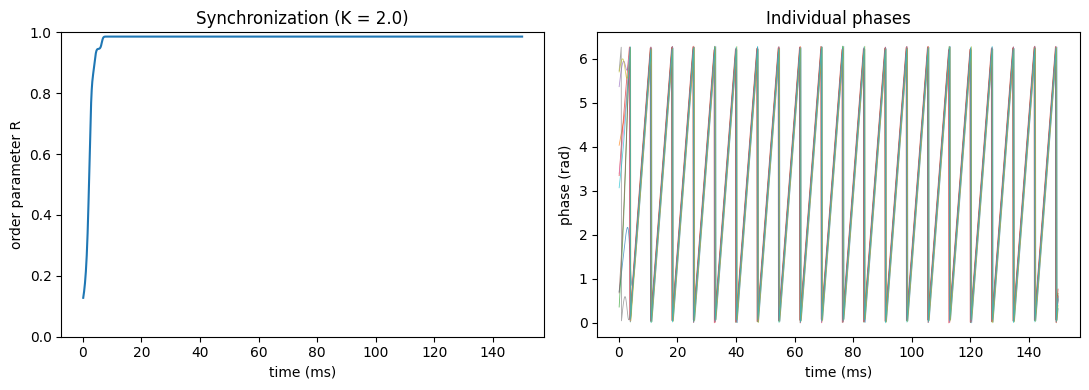

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(u.get_magnitude(res['ts']), R)
axes[0].set_xlabel('time (ms)'); axes[0].set_ylabel('order parameter R')
axes[0].set_ylim(0, 1); axes[0].set_title('Synchronization (K = 2.0)')
axes[1].plot(u.get_magnitude(res['ts']), np.mod(theta[:, ::5], 2 * np.pi),
             lw=0.6, alpha=0.7)
axes[1].set_xlabel('time (ms)'); axes[1].set_ylabel('phase (rad)')
axes[1].set_title('Individual phases')
plt.tight_layout()
plt.show()

## Try it: vary the coupling strength `K`

Sweep `K` across the synchronization transition: weak coupling stays incoherent (`R` low), strong coupling locks the population (`R` -> 1).

In [5]:
for K in [0.0, 1.0, 3.0]:
    m = brainmass.KuramotoNetwork(in_size=N, omega=omega, K=K, conn=np.ones((N, N)))
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(200. * u.ms, monitors=['theta'])
    th = u.get_magnitude(r['theta'])
    R_final = float(np.abs(np.mean(np.exp(1j * th[-50:]), axis=1)).mean())
    print(f'K = {K:.1f}  ->  steady order parameter R = {R_final:.3f}')

K = 0.0  ->  steady order parameter R = 0.078
K = 1.0  ->  steady order parameter R = 0.932
K = 3.0  ->  steady order parameter R = 0.994
